In [1]:
%load_ext autoreload
%autoreload 2

from math import pi
import os


os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'


import matplotlib.pyplot as plt
import numpy as np

from fluxoniumcr.dressed_control_fluxonium import (
    create_driven_fluxonium,
    calculate_avoided_crossing_gap,
)
from fluxoniumcr.qubits.fluxonium import Fluxonium

In [2]:
fx = Fluxonium(
    EJ=4.0 * 2*pi,
    EC=1.0 * 2*pi,
    EL=1.0 * 2*pi,
    dim=16,
    cutoff=128,
)
qubit_frequency = np.diff(fx.eigenvalues[:2]).item()
n_op = fx.get_operator('charge')
Ω0 = qubit_frequency/abs(n_op[0, 1])

In [3]:
drive_freq = 0.8 * 2*pi
floquet_basis = create_driven_fluxonium(
    fx,
    drive_freq,
    phase_gauge=True,
)

lookup_amps = np.linspace(0, 1, 50) * Ω0
floquet_basis.generate_lookup(lookup_amps, deg_tol=10e-3 * 2*pi)

In [4]:
pos, gap = calculate_avoided_crossing_gap(
    floquet_basis,
    1,
    5,
    -16,
    step_size=0.01 * Ω0,
    xtol=1e-9,
)
print("Gap [Hz]:", gap/(2*pi)*1e9)

Gap [Hz]: 0.0009267429551855474


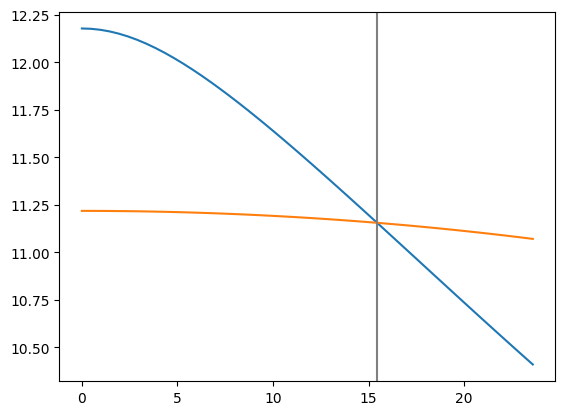

In [5]:
evals = np.array([
    floquet_basis.quasienergies(p)
    for p in lookup_amps
])

plt.plot(lookup_amps, evals[:, 1])
plt.plot(lookup_amps, evals[:, 5] - 16*drive_freq)
plt.axvline(pos, c='gray')